In [125]:
import act
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmweather

In [126]:
# get token
act.discovery.download_arm_data?

Signature:
act.discovery.download_arm_data(
    username,
    token,
    datastream,
    startdate,
    enddate,
    time=None,
    output=None,
)
Docstring:
This tool will help users utilize the ARM Live Data Webservice to download
ARM data.

Parameters
----------
username : str
    The username to use for logging into the ADC archive.
token : str
    The access token for accessing the ADC archive.
datastream : str
    The name of the datastream to acquire.
startdate : str
    The start date of the data to acquire. Formats accepted are
    YYYY-MM-DD, DD.MM.YYYY, DD/MM/YYYY, YYYYMMDD, YYYY/MM/DD or
    any of the previous formats with THH:MM:SS added onto the end
    (ex. 2020-09-15T12:00:00).
enddate : str
    The end date of the data to acquire. Formats accepted are
    YYYY-MM-DD, DD.MM.YYYY, DD/MM/YYYY, YYYYMMDD or YYYY/MM/DD, or
    any of the previous formats with THH:MM:SS added onto the end
    (ex. 2020-09-15T13:00:00).
time: str or None
    The specific time. Format is HHMMS

In [127]:
# Set your username and token here!
username = 'kbuglione'
token = '2bd15d0ec5d2e618'

# Set the datastream and start/enddates
datastream = 'kcgarsclkazr1kolliasM1.c0'
startdate = '2024-09-15'
enddate = '2024-09-20'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result = act.discovery.download_arm_data(username, token, datastream, startdate, enddate)

[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240919.000000.nc
[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240918.000000.nc
[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240920.000000.nc
[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240916.000000.nc
[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240917.000000.nc
[DOWNLOADING] kcgarsclkazr1kolliasM1.c0.20240915.000000.nc

If you use these data to prepare a publication, please cite:

Johnson, K., Giangrande, S., & Toto, T. Active Remote Sensing of CLouds (ARSCL)
product using Ka-band ARM Zenith Radars (ARSCLKAZR1KOLLIAS), 2024-09-15 to
2024-09-20, ARM Mobile Facility (KCG), kennaook ⁄ Cape Grim, Tasmania,
Australia; AMF2 (main site for CAPE-k) (M1). Atmospheric Radiation Measurement
(ARM) User Facility. https://doi.org/10.5439/1393437



In [128]:
# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result)

ds_kazrarscl

<xarray.Dataset> Size: 7GB
Dimensions:                               (time: 129600, height: 596,
                                           layer: 10, radar_mode: 4)
Coordinates:
  * time                                  (time) datetime64[ns] 1MB 2024-09-1...
  * layer                                 (layer) int32 40B 0 1 2 3 4 5 6 7 8 9
  * height                                (height) float32 2kB 160.0 ... 1.80...
  * radar_mode                            (radar_mode) |S2 8B b'hi' ... b'pr'
Data variables: (12/33)
    base_time                             (time) datetime64[ns] 1MB 2024-09-1...
    time_offset                           (time) datetime64[ns] 1MB 2024-09-1...
    reflectivity_best_estimate            (time, height) float32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    qc_reflectivity_best_estimate         (time, height) int32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    reflectivity                          (time, height) float32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    qc_reflectivity                       (time, height) int32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    ...                                    ...
    minimum_detectable_reflectivity_flag  (time, height) float32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    reflectivity_saturation_flag          (time, height) float32 309MB dask.array<chunksize=(901, 596), meta=np.ndarray>
    instrument_availability_flag          (time) int16 259kB dask.array<chunksize=(900,), meta=np.ndarray>
    lat                                   (time) float32 518kB -40.68 ... -40.68
    lon                                   (time) float32 518kB 144.7 ... 144.7
    alt                                   (time) float32 518kB 80.0 ... 80.0
Attributes: (12/23)
    command_line:                     idl -R -n kazrcfrarscl -s kcg -f M1 -b ...
    Conventions:                      ARM-1.2
    process_version:                  vap-kazrcfrarscl-1.6-15.el7
    dod_version:                      arsclkazr1kollias-c0-1.0
    site_id:                          kcg
    platform_id:                      arsclkazr1kollias
    ...                               ...
    doi:                              10.5439/1393437
    history:                          created by user malynn on machine node2...
    _file_dates:                      ['20240915', '20240916', '20240917', '2...
    _file_times:                      ['000000', '000000', '000000', '000000'...
    _datastream:                      kcgarsclkazr1kolliasM1.c0
    _arm_standards_flag:              1

<Axes: title={'center': 'kcgarsclkazr1kolliasM1.c0 reflectivity on 20240919'}, xlabel='Time [UTC]', ylabel='(m)'>

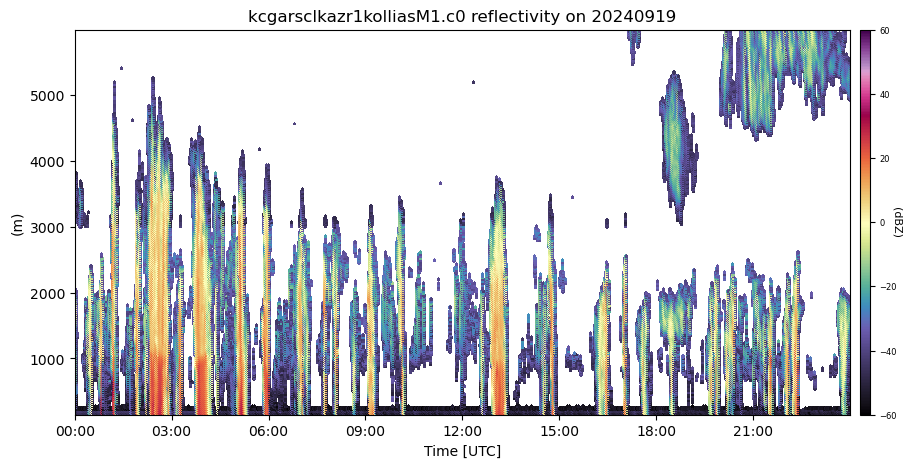

In [129]:
# ------- plot open MCC reflectivity

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])

# Let's take a look at the quality control information associated with a variable from the MPL
variable = 'reflectivity'

# Before we proceed to plotting, let's reduce the KZAR data down a little bit
# This will remove all data where heights are greater than 6000m
ds_kazrarscl = ds_kazrarscl.where(ds_kazrarscl.height <= 6000, drop=True)

# Next, let's take a look at visualizing the quality control information
display = act.plotting.TimeSeriesDisplay(ds_kazrarscl, figsize=(10, 5))

# Plot up the variable in the first plot
display.plot(variable, cmap='ChaseSpectral', vmin=-60, vmax=60)

Text(0.5, 1.0, 'Closed MCC')

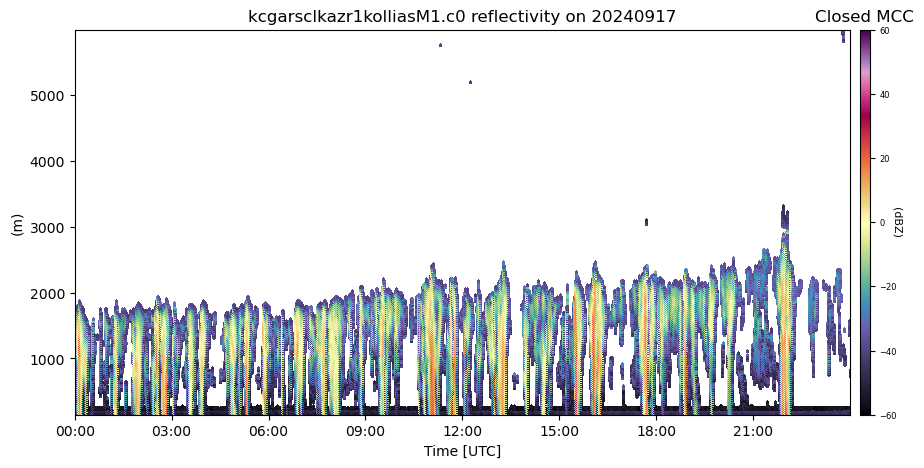

In [130]:
# ------- plot closed MCC reflectivity

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[2])

# Let's take a look at the quality control information associated with a variable from the MPL
variable = 'reflectivity'

# Before we proceed to plotting, let's reduce the MPL data down a little bit
# This will remove all data where heights are greater than 6000m
ds_kazrarscl = ds_kazrarscl.where(ds_kazrarscl.height <= 6000, drop=True)

# Next, let's take a look at visualizing the quality control information
# Create a plotting display object with 2 plots
display = act.plotting.TimeSeriesDisplay(ds_kazrarscl, figsize=(10, 5))

# Plot up the variable in the first plot
display.plot(variable, cmap='ChaseSpectral', vmin=-60, vmax=60)
plt.title('Closed MCC')

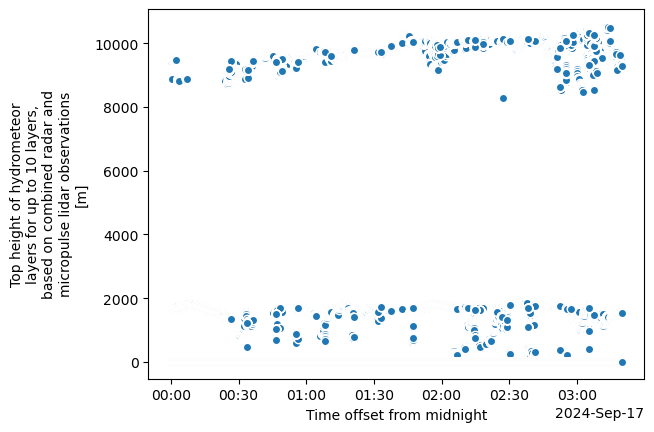

In [131]:
#cloud top height is sorted into layers of clouds (determined by the ceilometer) 
# --- every time there is a distinct change in dBz (e.g. from 40dBz to 0dBz), it considers that a cloud boundary
# --- there can be a different number of layers for each time in the series 

#cloud top heights for every layer
ds_kazrarscl.cloud_layer_top_height.isel(time=slice(0, 3000)).plot.scatter()

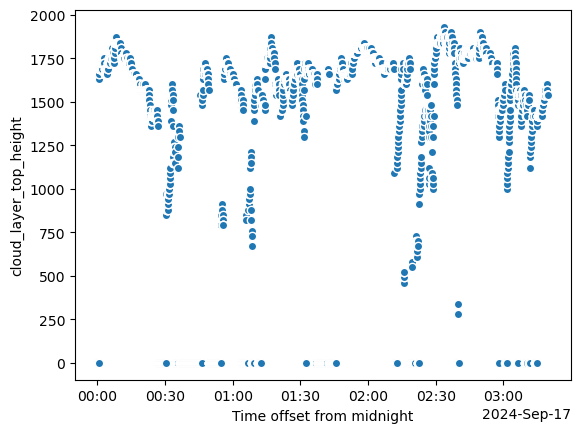

In [132]:
#filter heights less than 4000
ds_kazrarscl.cloud_layer_top_height.where(ds_kazrarscl.cloud_layer_top_height < 4_000).max(dim='layer').isel(time=slice(0, 3000)).plot.scatter()
#ds_kazrarscl.cloud_layer_top_height.where(ds_kazrarscl.cloud_layer_top_height < 4_000).max(dim='layer').sel(time=slice("2024-09-16T15","2024-09-16T18")).plot.scatter()

In [133]:
# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00"))

# find cloud top for clouds below 4000m and above 10m
cloud_top = subset.cloud_layer_top_height.where((subset.cloud_layer_top_height < 4_000) & (subset.cloud_layer_top_height > 10)).max(dim='layer')

#resample every minute to reduce noise
cloud_top_resampled = cloud_top.resample(time="1min").mean()

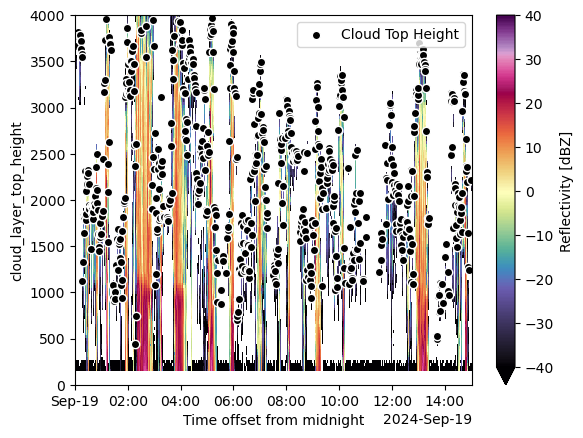

In [134]:
#plot subset of reflectivity
subset.reflectivity.plot(x='time', cmap='ChaseSpectral', vmin=-40, vmax=40)

#plot cloud top height on top of reflectivity 
cloud_top_resampled.plot.scatter(c='k', label='Cloud Top Height')

plt.ylim(0, 4000)
plt.legend(loc='upper right')

In [135]:
ref_to_plot = subset.reflectivity.where(subset.reflectivity > -35).compute()
ref_to_plot

<xarray.DataArray 'reflectivity' (time: 13515, height: 596)> Size: 32MB
array([[  9.176697 ,   8.379944 ,   6.446375 , ...,         nan,
                nan,         nan],
       [  4.815491 ,   4.374237 ,   3.3960667, ...,         nan,
                nan,         nan],
       [-11.737415 , -12.54369  , -13.6519985, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 108kB 2024-09-19 ... 2024-09-19T15:00:56
  * height   (height) float32 2kB 160.0 190.0 220.0 ... 1.798e+04 1.801e+04
Attributes:
    long_name:            Reflectivity
    units:                dBZ
    ancillary_variables:  qc_reflectivity
    valid_min:            -90.0
    valid_max:            50.0
    resolution:           0.001
    comment1:             Contains data from best radar operating mode (see r...
    comment2:             Reflectivity values have not yet been calibrated.  ...

In [136]:
!pip install xhistogram

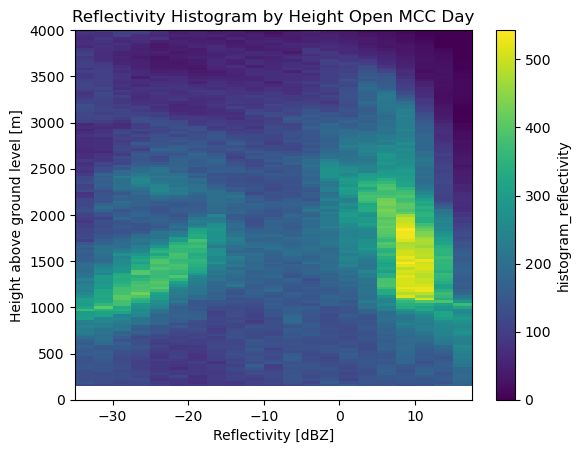

In [137]:
import xhistogram as histogram

ref = ref_to_plot #reflectivity values to plot 
bins = np.arange(-35, 20, 2.5) #range of reflectivity values
hist = histogram(ref, bins=bins, dim=["time"]) #histogram along time dimension
hist.plot()
plt.ylim(0, 4000)
plt.title(f"Reflectivity Histogram by Height Open MCC Day")
plt.show()
plt.close()

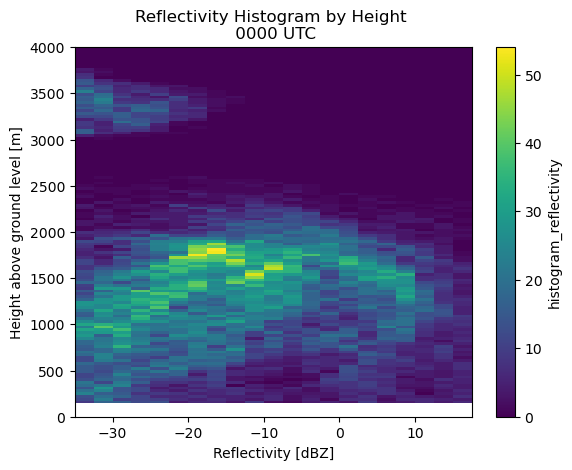

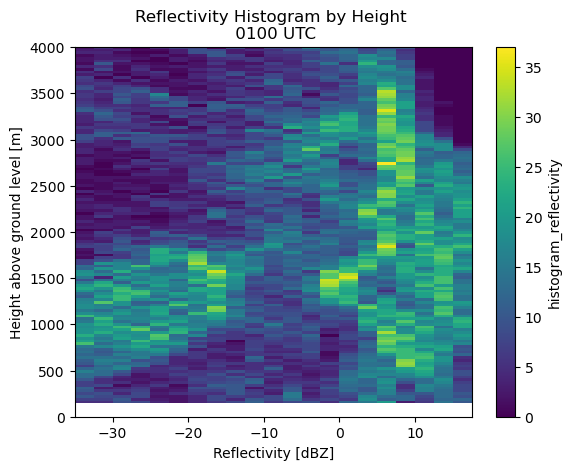

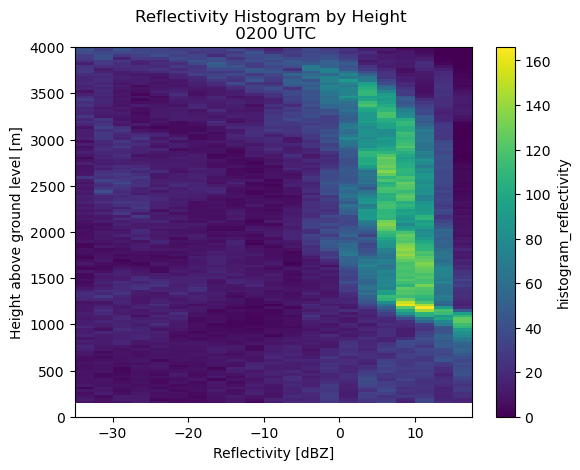

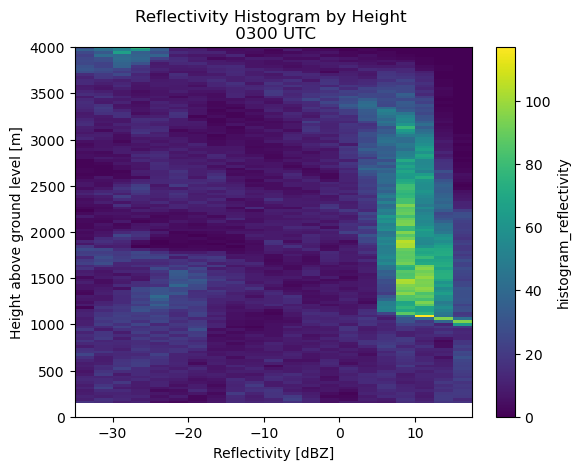

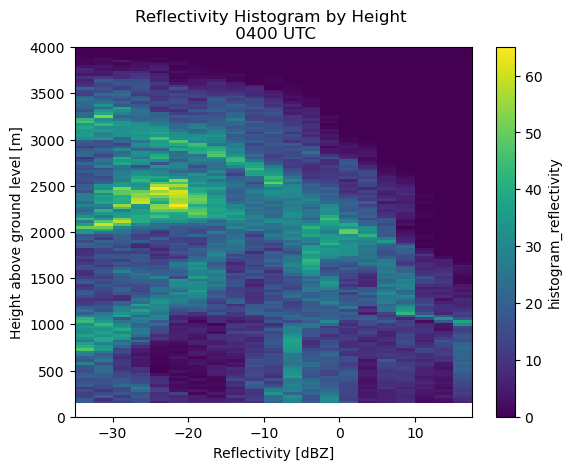

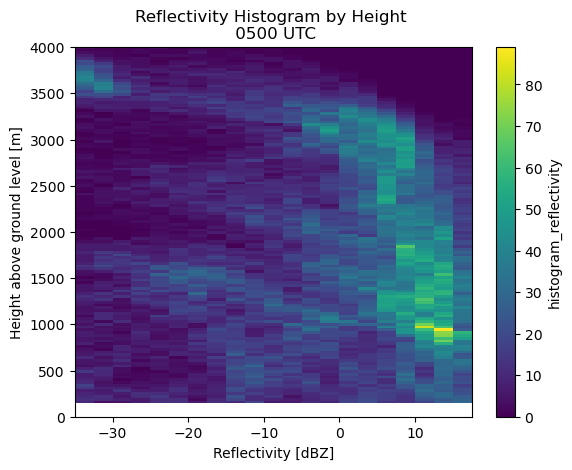

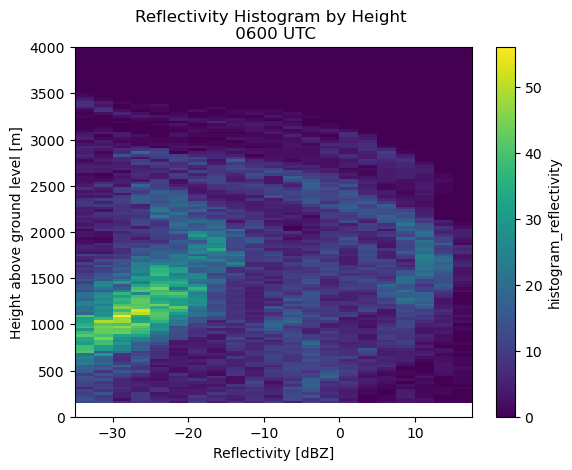

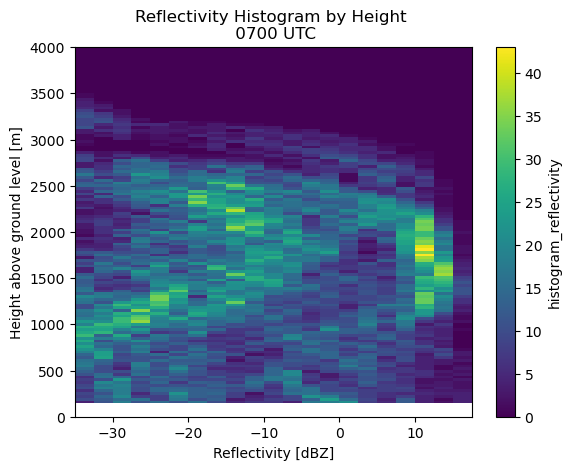

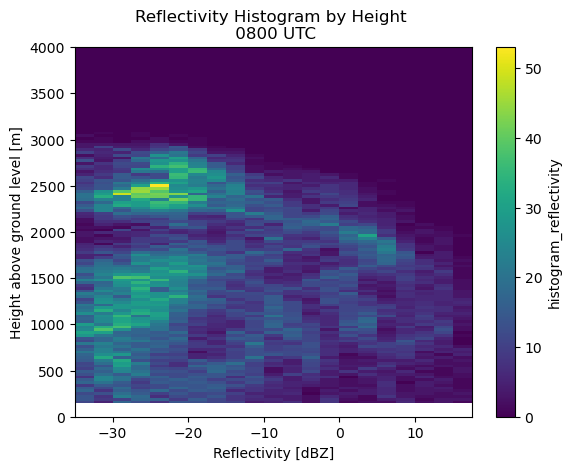

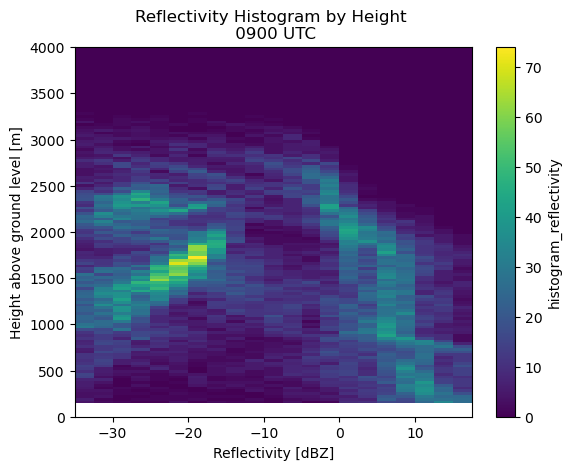

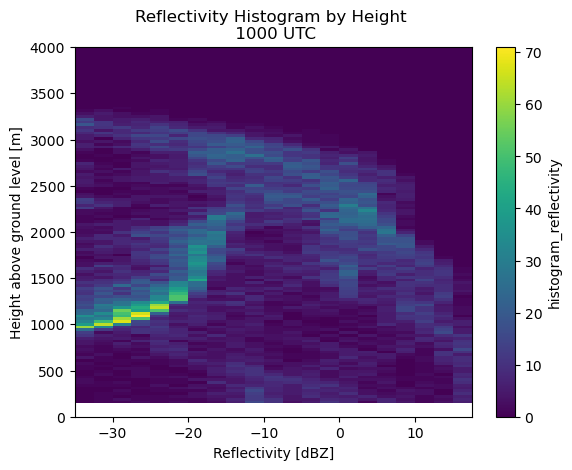

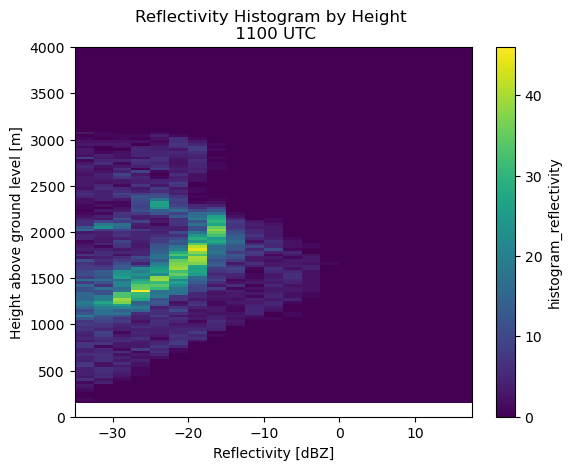

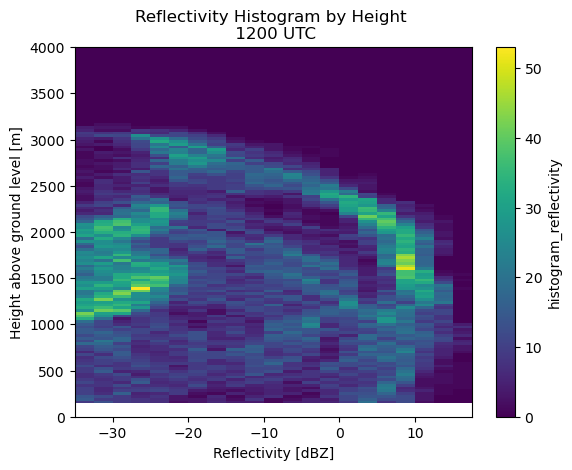

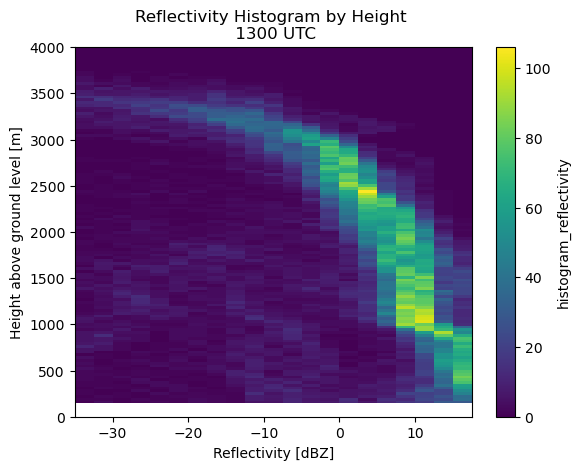

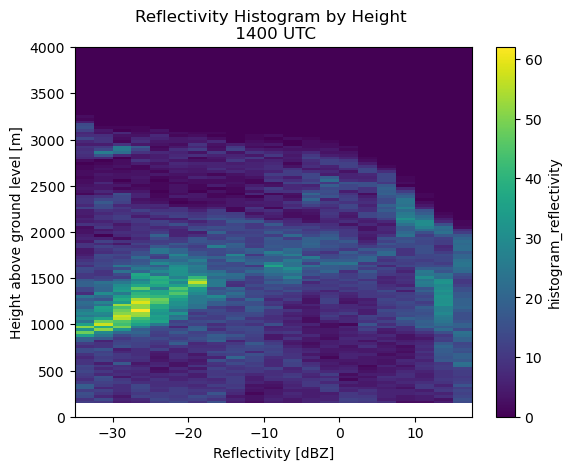

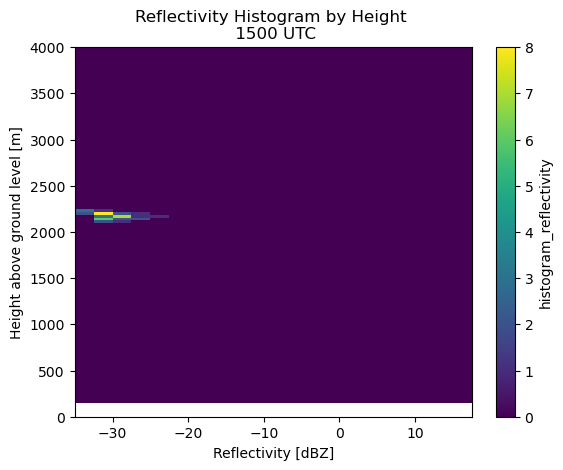

In [138]:
for hour in np.unique(ref_to_plot.time.dt.hour):
    h = f"{hour:02d}"
    ref = ref_to_plot.sel(time=f'2024-09-19T{h}')
    bins = np.arange(-35, 20, 2.5)
    hist = histogram(ref, bins=bins, dim=["time"])
    hist.plot()
    plt.ylim(0, 4000)
    plt.title(f"Reflectivity Histogram by Height \n {h}00 UTC")
    plt.show()
    plt.close()

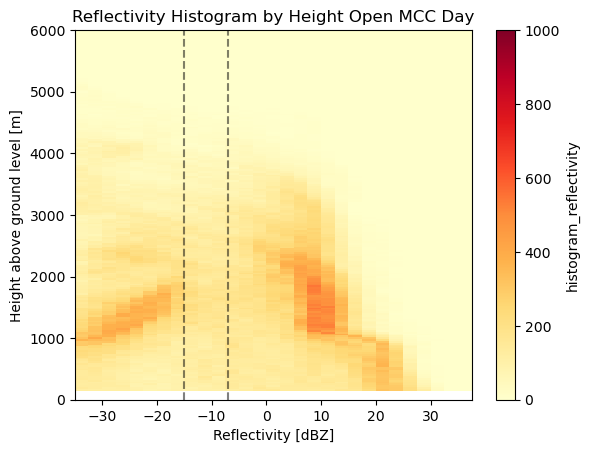

In [174]:
# --- Frequency of dBz values for open mcc cases 

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00"))

ref_to_plot = subset.reflectivity.where(subset.reflectivity > -35).compute()
ref_to_plot

cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -35).mean(dim='time')

plt.axvline(-15, c='black', linestyle='dashed', alpha = 0.5)
plt.axvline(-7, c='black', linestyle='dashed', alpha = 0.5)

ref = ref_to_plot
bins = np.arange(-35, 40, 2.5)
hist = histogram(ref, bins=bins, dim=["time"])
hist.plot(cmap ='YlOrRd', vmin=0, vmax=1000)
plt.ylim(0, 6000)
plt.title(f"Reflectivity Histogram by Height Open MCC Day")
plt.show()
plt.close()

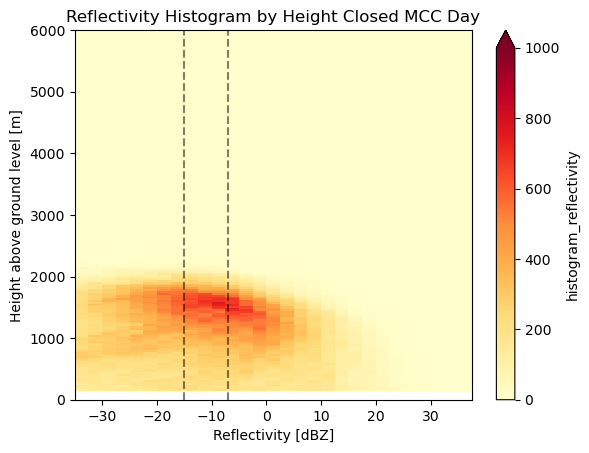

In [160]:
# --- Frequency of dBz values for open mcc cases 

# Let's read in the data using ACT and check out the data
ds_kazrarscl2 = act.io.read_arm_netcdf(result[2])

#create a subset of times to look at 
subset2 = ds_kazrarscl2.sel(time=slice("2024-09-17T00:00", "2024-09-17T15:00"))

ref_to_plot2 = subset2.reflectivity.where(subset2.reflectivity > -35).compute()
ref_to_plot2

cloud_dbz_mean2 = subset2.reflectivity.where(subset2.reflectivity > -35).mean(dim='time')

plt.axvline(-15, c='black', linestyle='dashed', alpha = 0.5)
plt.axvline(-7, c='black', linestyle='dashed', alpha = 0.5)

ref = ref_to_plot2
bins = np.arange(-35, 40, 2.5)
hist = histogram(ref, bins=bins, dim=["time"])
hist.plot(cmap ='YlOrRd', vmin=0, vmax=1000)
plt.ylim(0, 6000)
plt.title(f"Reflectivity Histogram by Height Closed MCC Day")
plt.show()
plt.close()

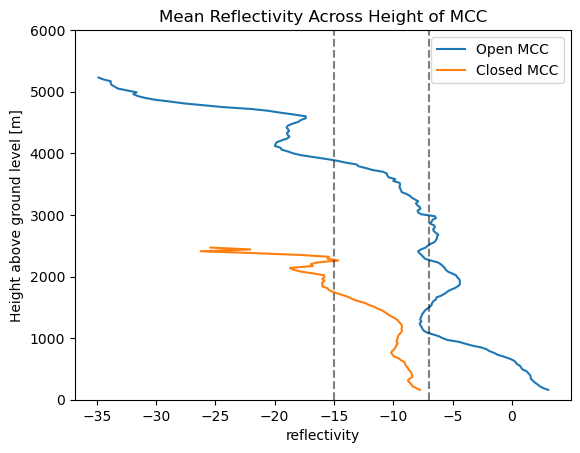

In [141]:
# --- Mean of dBz for each height across all times

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])
ds_kazrarscl2 = act.io.read_arm_netcdf(result[2])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00"))
subset2 = ds_kazrarscl2.sel(time=slice("2024-09-17T00:00", "2024-09-17T15:00"))

cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -35).mean(dim='time')
cloud_dbz_mean2 = subset2.reflectivity.where(subset2.reflectivity > -35).mean(dim='time')

cloud_dbz_mean.plot(y='height')
cloud_dbz_mean2.plot(y='height')

plt.axvline(-15, c='black', linestyle='dashed', alpha = 0.5)
plt.axvline(-7, c='black', linestyle='dashed', alpha = 0.5)

plt.ylim(0,6000)
plt.title('Mean Reflectivity Across Height of MCC')
plt.legend(['Open MCC', 'Closed MCC'])

#Huang et al. 2016
# > -15dBz is drizzle 
# > -7dBz is rain

0.4750277469478357

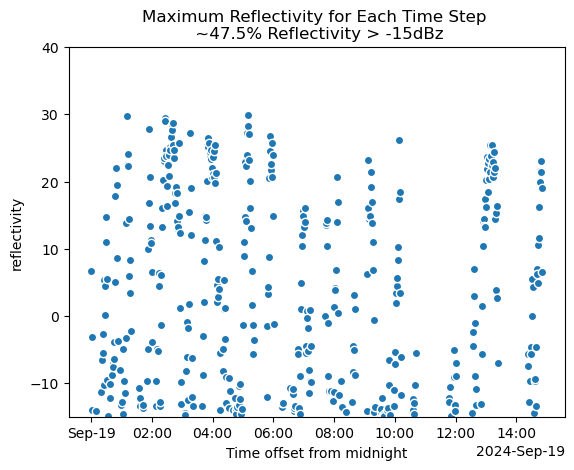

In [142]:
# --- find frequency of rain events for open MCCs (reflectivity > -15 dBz)

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00"))

cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -15).max(dim='height')

#resample every minute to reduce noise
cloud_dbz_resampled = cloud_dbz_mean.resample(time="1min").mean()

#plot the data
cloud_dbz_resampled.plot.scatter(x='time')
plt.ylim(-15,40)
plt.title('Maximum Reflectivity for Each Time Step \n ~47.5% Reflectivity > -15dBz')

#drop the nan values to count the number of 
len(cloud_dbz_resampled.dropna(dim='time'))/len(cloud_dbz_resampled)

0.7081021087680355

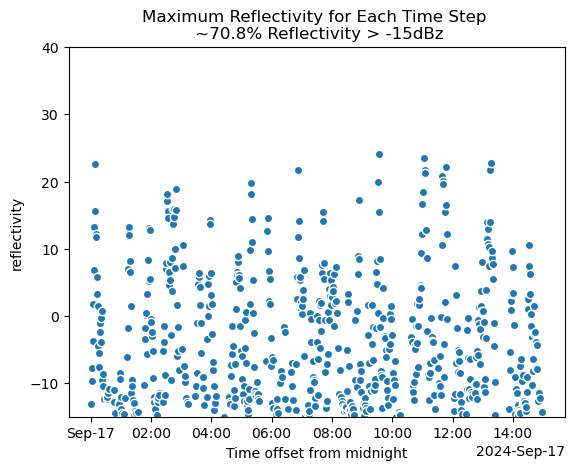

In [143]:
# --- find frequency of rain events for closed MCCs (reflectivity > -15 dBz)

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[2])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-17T00:00", "2024-09-17T15:00"))

cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -15).max(dim='height')

#resample every minute to reduce noise -- resampled by mean
cloud_dbz_resampled = cloud_dbz_mean.resample(time="1min").mean()

#plot the data
cloud_dbz_resampled.plot.scatter(x='time')
plt.ylim(-15,40)
plt.title('Maximum Reflectivity for Each Time Step \n ~70.8% Reflectivity > -15dBz')

len(cloud_dbz_resampled.dropna(dim='time'))/len(cloud_dbz_resampled)

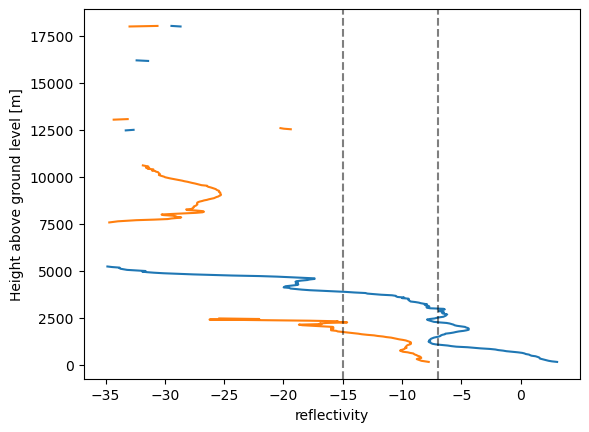

In [144]:
# --- Mean of dBz for each height across all times

# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])
ds_kazrarscl2 = act.io.read_arm_netcdf(result[2])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00"))
subset2 = ds_kazrarscl2.sel(time=slice("2024-09-17T00:00", "2024-09-17T15:00"))

cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -35).mean(dim='time')
cloud_dbz_mean2 = subset2.reflectivity.where(subset2.reflectivity > -35).mean(dim='time')

#cloud_dbz_mean = subset.reflectivity.mean(dim='time')
#cloud_dbz_mean2 = subset2.reflectivity.mean(dim='time')

cloud_dbz_mean.plot(y='height')
cloud_dbz_mean2.plot(y='height')

plt.axvline(-15, c='black', linestyle='dashed', alpha = 0.5)
plt.axvline(-7, c='black', linestyle='dashed', alpha = 0.5)

#plt.ylim(0,6000)
#plt.title('Mean Reflectivity Across Height of MCC')
#plt.legend(['Open MCC', 'Closed MCC'])

#Huang et al. 2016
# > -15dBz is drizzle 
# > -7dBz is rain

In [145]:
# Let's read in the data using ACT and check out the data
ds_kazrarscl = act.io.read_arm_netcdf(result[4])
#ds_kazrarscl2 = act.io.read_arm_netcdf(result[2])

#create a subset of times to look at 
subset = ds_kazrarscl.sel(time=slice("2024-09-19T00:00", "2024-09-19T15:00")).reflectivity
#subset2 = ds_kazrarscl2.sel(time=slice("2024-09-17T00:00", "2024-09-17T15:00"))

reflect = subset.resample(time="1min").mean()
reflect = reflect.sel(height=slice("0","6000"))

reflect

<xarray.DataArray 'reflectivity' (time: 901, height: 195)> Size: 703kB
dask.array<getitem, shape=(901, 195), dtype=float32, chunksize=(1, 195), chunktype=numpy.ndarray>
Coordinates:
  * height   (height) float32 780B 160.0 190.0 220.0 ... 5.95e+03 5.98e+03
  * time     (time) datetime64[ns] 7kB 2024-09-19 ... 2024-09-19T15:00:00
Attributes:
    long_name:            Reflectivity
    units:                dBZ
    ancillary_variables:  qc_reflectivity
    valid_min:            -90.0
    valid_max:            50.0
    resolution:           0.001
    comment1:             Contains data from best radar operating mode (see r...
    comment2:             Reflectivity values have not yet been calibrated.  ...

In [146]:
time_steps = 901
height_levels = 195

reflectivity_bins = np.arange(-35, 10, 1)  # Adjust the bin range and size as needed
height_bins = np.arange(195)  # Assuming each index in the second dimension represents a height level
frequency = np.zeros((len(reflectivity_bins)-1, len(height_bins)))
for t in range(time_steps):
    for h in range(height_levels):
        reflectivity = reflect[t, h]
        if np.isnan(reflectivity):
            continue
        reflectivity_bin = np.digitize(reflectivity, reflectivity_bins) - 1
        height_bin = h
        if 0 <= reflectivity_bin < len(reflectivity_bins)-1:
            frequency[reflectivity_bin, height_bin] += 1
frequency = frequency / time_steps
frequency_xr = xr.DataArray(frequency, coords={'Reflectivity':reflectivity_bins[:-1], 'Height':height_bins}, dims=['Reflectivity','Height'], name='frequency')

# Let's try a heatmap with this as well!
display = act.plotting.DistributionDisplay(frequency_xr, figsize=(12, 5))
display.plot_heatmap('Reflectivity', 'Height', x_bins=50, y_bins=50, threshold=0)


plt.ylim(0,6000)
plt.title('Mean Reflectivity Across Height of MCC')
plt.legend(['Open MCC', 'Closed MCC'])

KeyboardInterrupt: 

In [ ]:
cloud_dbz_mean = subset.reflectivity.where(subset.reflectivity > -35).mean(dim='time')
#cloud_dbz_mean2 = subset2.reflectivity.where(subset2.reflectivity > -35).mean(dim='time')

#cloud_dbz_mean = subset.reflectivity.mean(dim='time')
#cloud_dbz_mean2 = subset2.reflectivity.mean(dim='time')

cloud_dbz_mean.plot(y='height')
#cloud_dbz_mean2.plot(y='height')

plt.axvline(-15, c='black', linestyle='dashed', alpha = 0.5)
plt.axvline(-7, c='black', linestyle='dashed', alpha = 0.5)

# Let's try a heatmap with this as well!
display = act.plotting.DistributionDisplay(frequency_xr, figsize=(12, 5))
display.plot_heatmap('Reflectivity', 'Height', x_bins=50, y_bins=50, threshold=0)


plt.ylim(0,6000)
plt.title('Mean Reflectivity Across Height of MCC')
plt.legend(['Open MCC', 'Closed MCC'])

#Huang et al. 2016
# > -15dBz is drizzle 
# > -7dBz is rain